## Evaluación de las métricas obtenidas para cada modelo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import seaborn as sns

In [22]:
data_base = pd.read_csv('../data/data_base.csv')

### Retornos del Mercado S&P500

    year  market_cap_weighted_return  cumulative_return
0   2004                    0.065330           1.065330
1   2005                    0.116894           1.189861
2   2006                    0.114718           1.326359
3   2007                   -0.049458           1.260760
4   2008                   -0.364890           0.800722
5   2009                    0.494581           1.196743
6   2010                    0.149998           1.376253
7   2011                    0.084117           1.492019
8   2012                    0.145784           1.709531
9   2013                    0.215612           2.078128
10  2014                    0.127965           2.344056
11  2015                    0.018677           2.387836
12  2016                    0.168056           2.789126
13  2017                    0.135019           3.165712
14  2018                    0.090394           3.451874
15  2019                   -0.073120           3.199472
16  2020                    0.593059           5

C:\Users\Ignacio\AppData\Local\Temp\ipykernel_2056\3949099731.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_avg_return)


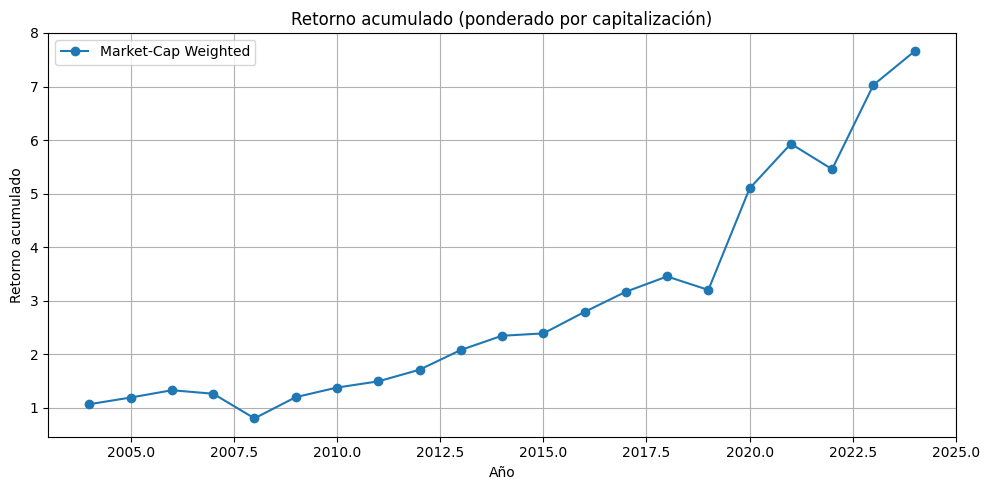

In [23]:
# Asegurar columna de año
data_base['date'] = pd.to_datetime(data_base['date'])
data_base['year'] = data_base['date'].dt.year

# Suponiendo que market_cap está al comienzo del año y no contiene nulos
df_valid = data_base[
    (data_base['year'] >= 2004) & 
    (~data_base['target_12m_final'].isna()) & 
    (~data_base['marketcap'].isna())
][['year', 'target_12m_final', 'marketcap']]

# Calcular retorno ponderado por capitalización
def weighted_avg_return(group):
    weights = group['marketcap']
    returns = group['target_12m_final']
    return np.average(returns, weights=weights)

metrics_sp500 = (
    df_valid.groupby('year')
    .apply(weighted_avg_return)
    .reset_index(name='market_cap_weighted_return')
)

# Calcular retorno acumulado
metrics_sp500['cumulative_return'] = (1 + metrics_sp500['market_cap_weighted_return']).cumprod()

# Mostrar
print(metrics_sp500)

# Graficar
plt.figure(figsize=(10,5))
plt.plot(metrics_sp500['year'], metrics_sp500['cumulative_return'], marker='o', label='Market-Cap Weighted')
plt.title("Retorno acumulado (ponderado por capitalización)")
plt.xlabel("Año")
plt.ylabel("Retorno acumulado")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Importación de resultados para las Estrategias desarrolladas

In [24]:
cm_ridge = pd.read_csv('../result_metrics/cm_ridge.csv', index_col=0)
cm_xgboost = pd.read_csv('../result_metrics/cm_xgboost.csv', index_col=0)
cm_dnn = pd.read_csv('../result_metrics/cm_dnn.csv', index_col=0)
cm_dnn2 = pd.read_csv('../result_metrics/cm_dnn2.csv', index_col=0)

metrics_ridge = pd.read_csv('../result_metrics/metrics_ridge_classifier.csv')
metrics_xgboost = pd.read_csv('../result_metrics/metrics_xgboost.csv')
metrics_dnn = pd.read_csv('../result_metrics/metrics_dnn.csv')
metrics_dnn2 = pd.read_csv('../result_metrics/metrics_dnn2.csv')

tickers_ridge = pd.read_csv('../result_metrics/tickers_ridge.csv')
tickers_xgboost = pd.read_csv('../result_metrics/tickers_xgboost.csv')
tickers_dnn = pd.read_csv('../result_metrics/tickers_dnn.csv')
tickers_dnn2 = pd.read_csv('../result_metrics/tickers_dnn2.csv')


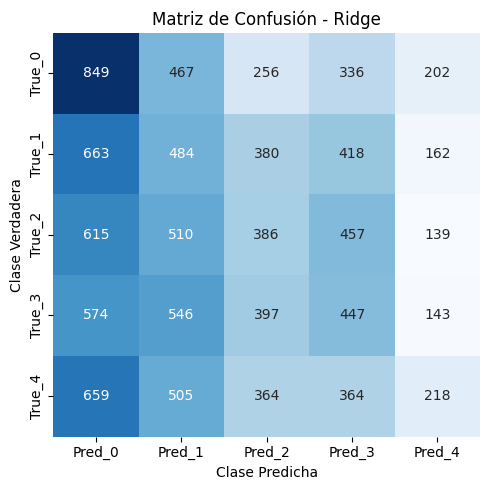

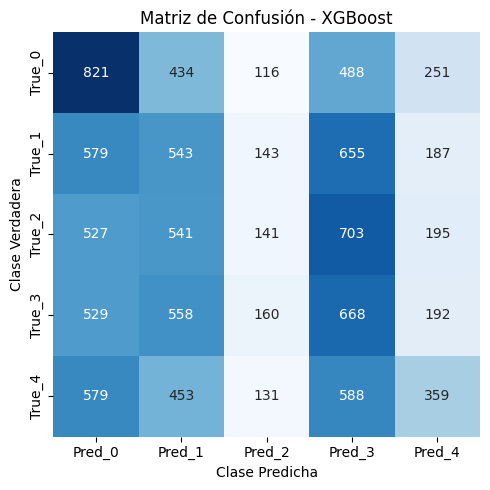

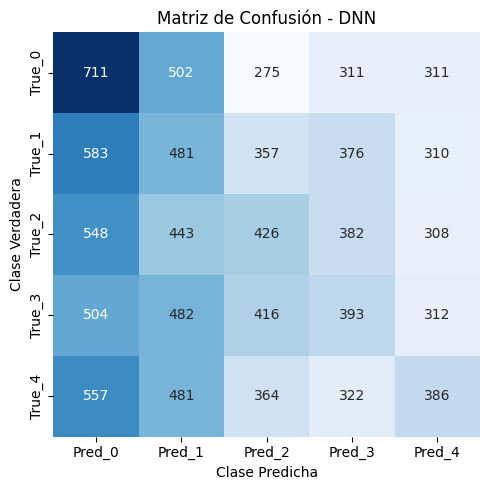

In [41]:
# Función para visualizar una matriz de confusión
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.ylabel('Clase Verdadera')
    plt.xlabel('Clase Predicha')
    plt.tight_layout()
    plt.show()

# Mostrar las 3 matrices
plot_confusion_matrix(cm_ridge, "Matriz de Confusión - Ridge")
plot_confusion_matrix(cm_xgboost, "Matriz de Confusión - XGBoost")
# plot_confusion_matrix(cm_dnn, "Matriz de Confusión - DNN")
plot_confusion_matrix(cm_dnn2, "Matriz de Confusión - DNN")

In [44]:
# DNN2
n_correct_class4 = (tickers_dnn2['target_class'] == 4).sum()
precision_top20 = n_correct_class4 / len(tickers_dnn2)
print(f"Precisión sobre top 20 seleccionadas (DNN2): {precision_top20:.4f}")
print(f"Precisión sobre la Clase 4 (DNN2): {metrics_dnn2['precision_4'].mean():.4f}")
print("-------")

# XGBoost
n_correct_class4 = (tickers_xgboost['target_class'] == 4).sum()
precision_top20 = n_correct_class4 / len(tickers_xgboost)
print(f"Precisión sobre top 20 seleccionadas (XGBoost): {precision_top20:.4f}")
print(f"Precisión sobre la Clase 4 (XGBoost): {metrics_xgboost['precision_4'].mean():.4f}")
print("-------")

# Ridge
n_correct_class4 = (tickers_ridge['target_class'] == 4).sum()
precision_top20 = n_correct_class4 / len(tickers_ridge)
print(f"Precisión sobre top 20 seleccionadas (Ridge): {precision_top20:.4f}")
print(f"Precisión sobre la Clase 4 (Ridge): {metrics_ridge['precision_4'].mean():.4f}")




Precisión sobre top 20 seleccionadas (DNN2): 0.2738
Precisión sobre la Clase 4 (DNN2): 0.2207
-------
Precisión sobre top 20 seleccionadas (XGBoost): 0.2833
Precisión sobre la Clase 4 (XGBoost): 0.3073
-------
Precisión sobre top 20 seleccionadas (Ridge): 0.2548
Precisión sobre la Clase 4 (Ridge): 0.2298


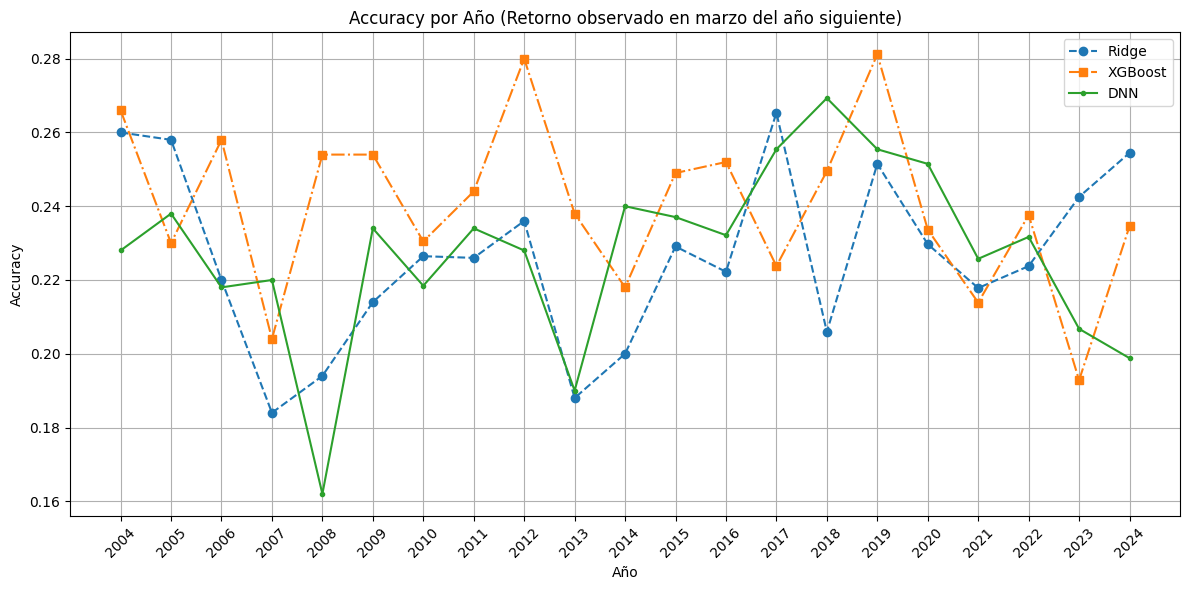

In [45]:
import matplotlib.pyplot as plt

# Ajustar año para representar el 31 de marzo del año siguiente
metrics_ridge['adjusted_year'] = metrics_ridge['year'] 
metrics_xgboost['adjusted_year'] = metrics_xgboost['year'] 
#metrics_dnn['adjusted_year'] = metrics_dnn['year'] 
metrics_dnn2['adjusted_year'] = metrics_dnn2['year'] 

plt.figure(figsize=(12, 6))
plt.plot(metrics_ridge['adjusted_year'], metrics_ridge['accuracy'], label='Ridge', marker='o', linestyle='--')
plt.plot(metrics_xgboost['adjusted_year'], metrics_xgboost['accuracy'], label='XGBoost', marker='s', linestyle='-.')
#plt.plot(metrics_dnn['adjusted_year'], metrics_dnn['accuracy'], label='DNN', marker='^', linestyle='-')
plt.plot(metrics_dnn2['adjusted_year'], metrics_dnn2['accuracy'], label='DNN', marker='.', linestyle='-')

plt.xlabel('Año')
plt.ylabel('Accuracy')
plt.title('Accuracy por Año (Retorno observado en marzo del año siguiente)')
plt.xticks(ticks=metrics_ridge['adjusted_year'], labels=metrics_ridge['adjusted_year'], rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


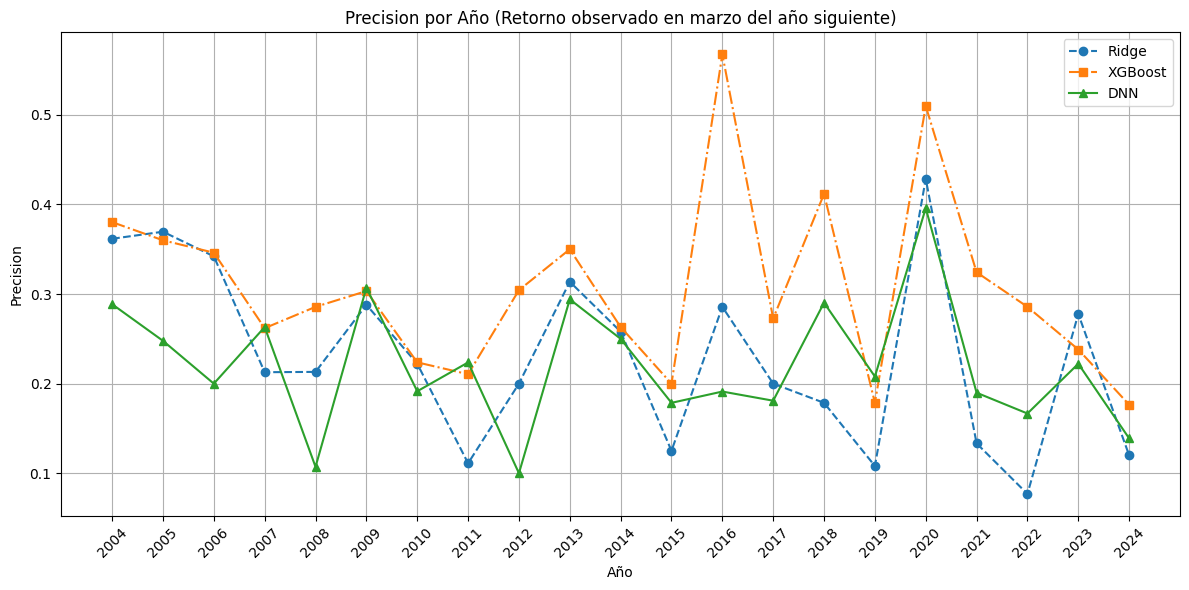

In [52]:
# Ajustar año para representar el 31 de marzo del año siguiente
metrics_ridge['adjusted_year'] = metrics_ridge['year'] 
metrics_xgboost['adjusted_year'] = metrics_xgboost['year'] 
# metrics_dnn['adjusted_year'] = metrics_dnn['year'] 
metrics_dnn2['adjusted_year'] = metrics_dnn2['year'] 

plt.figure(figsize=(12, 6))
plt.plot(metrics_ridge['adjusted_year'], metrics_ridge['precision_4'], label='Ridge', marker='o', linestyle='--')
plt.plot(metrics_xgboost['adjusted_year'], metrics_xgboost['precision_4'], label='XGBoost', marker='s', linestyle='-.')
# plt.plot(metrics_dnn['adjusted_year'], metrics_dnn['precision_4'], label='DNN', marker='^', linestyle='-')
plt.plot(metrics_dnn2['adjusted_year'], metrics_dnn2['precision_4'], label='DNN', marker='^', linestyle='-')

plt.xlabel('Año')
plt.ylabel('Precision')
plt.title('Precision por Año (Retorno observado en marzo del año siguiente)')
plt.xticks(ticks=metrics_ridge['adjusted_year'], labels=metrics_ridge['adjusted_year'], rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


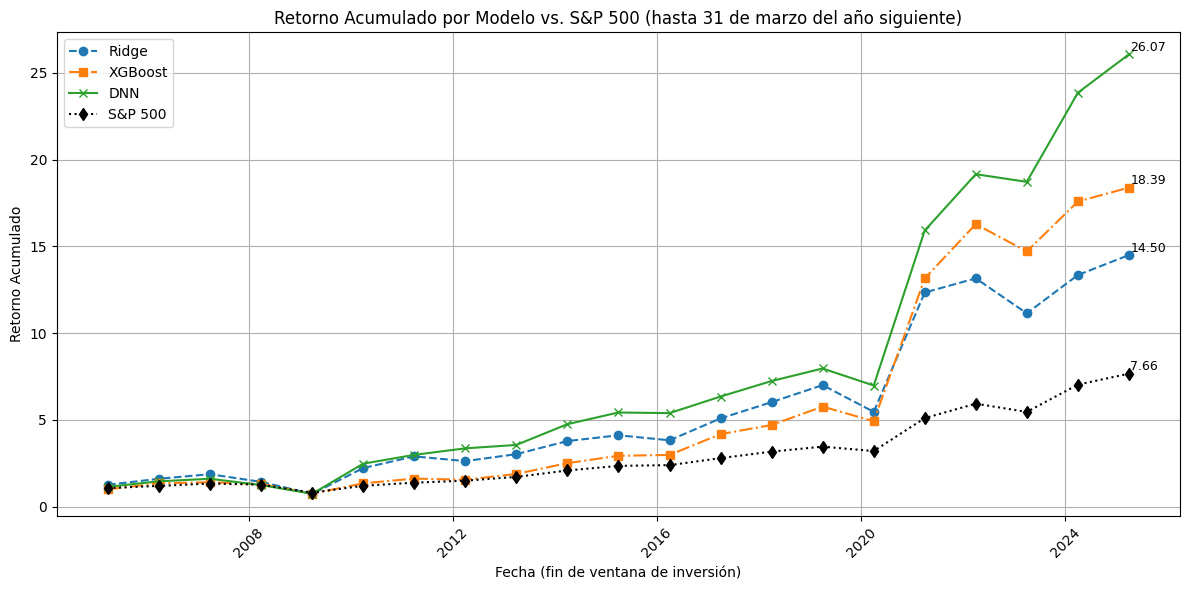

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegúrate de tener la columna 'fecha' en todos los DataFrames
for df in [metrics_ridge, metrics_xgboost, metrics_dnn, metrics_sp500, metrics_dnn2]:
    df['fecha'] = pd.to_datetime(df['year'] + 1, format='%Y') + pd.DateOffset(months=2, days=30)

plt.figure(figsize=(12, 6))

# Ridge
plt.plot(metrics_ridge['fecha'], metrics_ridge['cumulative_return'], label='Ridge', marker='o', linestyle='--')
plt.text(metrics_ridge['fecha'].iloc[-1] + pd.Timedelta(days=10),
         metrics_ridge['cumulative_return'].iloc[-1] + 0.2,
         f"{metrics_ridge['cumulative_return'].iloc[-1]:.2f}",
         fontsize=9, ha='left')

# XGBoost
plt.plot(metrics_xgboost['fecha'], metrics_xgboost['cumulative_return'], label='XGBoost', marker='s', linestyle='-.')
plt.text(metrics_xgboost['fecha'].iloc[-1] + pd.Timedelta(days=10),
         metrics_xgboost['cumulative_return'].iloc[-1] + 0.2,
         f"{metrics_xgboost['cumulative_return'].iloc[-1]:.2f}",
         fontsize=9, ha='left')

# DNN
# plt.plot(metrics_dnn['fecha'], metrics_dnn['cumulative_return'], label='DNN', marker='^', linestyle='-')
# plt.text(metrics_dnn['fecha'].iloc[-1] + pd.Timedelta(days=10),
#          metrics_dnn['cumulative_return'].iloc[-1] + 0.2,
#          f"{metrics_dnn['cumulative_return'].iloc[-1]:.2f}",
#          fontsize=9, ha='left')

# DNN
plt.plot(metrics_dnn2['fecha'], metrics_dnn2['cumulative_return'], label='DNN', marker='x', linestyle='-')
plt.text(metrics_dnn2['fecha'].iloc[-1] + pd.Timedelta(days=10),
         metrics_dnn2['cumulative_return'].iloc[-1] + 0.2,
         f"{metrics_dnn2['cumulative_return'].iloc[-1]:.2f}",
         fontsize=9, ha='left')


# SP500
plt.plot(metrics_sp500['fecha'], metrics_sp500['cumulative_return'], label='S&P 500', marker='d', linestyle=':', color='black')
plt.text(metrics_sp500['fecha'].iloc[-1] + pd.Timedelta(days=10),
         metrics_sp500['cumulative_return'].iloc[-1] + 0.2,
         f"{metrics_sp500['cumulative_return'].iloc[-1]:.2f}",
         fontsize=9, ha='left')

# Estética del gráfico
plt.title('Retorno Acumulado por Modelo vs. S&P 500 (hasta 31 de marzo del año siguiente)')
plt.xlabel('Fecha (fin de ventana de inversión)')
plt.ylabel('Retorno Acumulado')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
# Calcular volatilidades
ridge_vol = metrics_ridge['mean_return_class4'].std()
xgb_vol = metrics_xgboost['mean_return_class4'].std()
dnn_vol = metrics_dnn['mean_return_top20'].std()
dnn_vol2 = metrics_dnn2['mean_return_top20'].std()
sp500_vol = metrics_sp500['market_cap_weighted_return'].std()

# Obtener peor año (índice del valor mínimo)
ridge_idx = metrics_ridge['mean_return_class4'].idxmin()
xgb_idx = metrics_xgboost['mean_return_class4'].idxmin()
dnn_idx = metrics_dnn['mean_return_top20'].idxmin()
dnn_idx2 = metrics_dnn2['mean_return_top20'].idxmin()
sp500_idx = metrics_sp500['market_cap_weighted_return'].idxmin()

# Extraer datos de los peores años
ridge_worst_year = metrics_ridge.loc[ridge_idx, 'year']
ridge_worst_ret = metrics_ridge.loc[ridge_idx, 'mean_return_class4']

xgb_worst_year = metrics_xgboost.loc[xgb_idx, 'year']
xgb_worst_ret = metrics_xgboost.loc[xgb_idx, 'mean_return_class4']

dnn_worst_year = metrics_dnn.loc[dnn_idx, 'year']
dnn_worst_ret = metrics_dnn.loc[dnn_idx, 'mean_return_top20']

dnn_worst_year2 = metrics_dnn2.loc[dnn_idx2, 'year']
dnn_worst_ret2 = metrics_dnn2.loc[dnn_idx2, 'mean_return_top20']

sp500_worst_year = metrics_sp500.loc[sp500_idx, 'year']
sp500_worst_ret = metrics_sp500.loc[sp500_idx, 'market_cap_weighted_return']

# Promedios de métricas
ridge_avg = metrics_ridge[['accuracy', 'precision_4', 'recall_4']].mean()
xgb_avg = metrics_xgboost[['accuracy', 'precision_4', 'recall_4']].mean()
dnn_avg = metrics_dnn[['accuracy', 'precision_4', 'recall_4']].mean()
dnn_avg2 = metrics_dnn2[['accuracy', 'precision_4', 'recall_4']].mean()




# Años entre el inicio y el final del período
years = 2025 - 2004  # Desde 31/3/2004 hasta 31/3/2025 => 21 años

# Retornos cumulativos (ejemplos, deben estar previamente calculados)
ridge_cum_return = metrics_ridge['cumulative_return'].iloc[-1]
xgb_cum_return = metrics_xgboost['cumulative_return'].iloc[-1]
dnn_cum_return = metrics_dnn['cumulative_return'].iloc[-1]
dnn_cum_return2 = metrics_dnn2['cumulative_return'].iloc[-1]
sp500_cum_return = metrics_sp500['cumulative_return'].iloc[-1]

# Cálculo de CAGR
ridge_cagr = ((ridge_cum_return) ** (1 / years) - 1)*100
xgb_cagr = ((xgb_cum_return) ** (1 / years) - 1)*100
dnn_cagr = ((dnn_cum_return) ** (1 / years) - 1)*100
dnn_cagr2 = ((dnn_cum_return2) ** (1 / years) - 1)*100
sp500_cagr = ((sp500_cum_return) ** (1 / years) - 1)*100



# Crear resumen en DataFrame
summary_df = pd.DataFrame({
    'Modelo': ['Ridge', 'XGBoost', 'DNN', 'DNN2', 'S&P 500'],
    'Volatilidad': [ridge_vol, xgb_vol, dnn_vol, dnn_vol2, sp500_vol],
    'Peor año': [ridge_worst_year, xgb_worst_year, dnn_worst_year,dnn_worst_year2, sp500_worst_year],
    'Retorno peor año': [ridge_worst_ret, xgb_worst_ret, dnn_worst_ret,dnn_worst_ret2, sp500_worst_ret],
    'Accuracy medio': [ridge_avg['accuracy'], xgb_avg['accuracy'], dnn_avg['accuracy'], dnn_avg2['accuracy'], None],
    'Precision_4 media': [ridge_avg['precision_4'], xgb_avg['precision_4'], dnn_avg['precision_4'],dnn_avg2['precision_4'], None],
    'Recall_4 medio': [ridge_avg['recall_4'], xgb_avg['recall_4'], dnn_avg['recall_4'],dnn_avg2['recall_4'], None],
    'CAGR (%)': [round(ridge_cagr,3), round(xgb_cagr,3), round(dnn_cagr,3), round(dnn_cagr2,3), round(sp500_cagr,3)]
})

# Mostrar resultados
display(summary_df)


,Modelo,Volatilidad,Peor año,Retorno peor año,Accuracy medio,Precision_4 media,Recall_4 medio,CAGR (%)
0,Ridge,0.536188,2008,-0.488685,0.226135,0.229827,0.103470,13.580
1,XGBoost,0.417945,2008,-0.430794,0.240214,0.307344,0.170476,14.872
2,DNN,0.464888,2008,-0.534215,0.220451,0.218342,0.200523,15.628
3,DNN2,0.576782,2008,-0.407036,0.227348,0.220739,0.183032,16.798
4,S&P 500,0.195605,2008,-0.364890,NaN,NaN,NaN,10.181


In [34]:
print(metrics_ridge.columns)


Index(['accuracy', 'precision_4', 'recall_4', 'mean_return_class4',
       'volatility_class4', 'tickers', 'cumulative_return'],
      dtype='object')
